# Neural Network Evaluation: `MLPClassifier` on `dataset_stratified.csv`

- **Model:** `sklearn.neural_network.MLPClassifier`
- **Optimizer constraint:** `solver='sgd'`, `momentum=0`, `nesterovs_momentum=False`
- **Training/validation source:** sampled/stratified dataset from `DATA_PATH`
- **Test source:** untouched remaining dataset from `DATA_PATH_TEST`
- **Primary model-selection metric:** macro-F1, because the dataset is multiclass and imbalanced

The notebook produces the outputs:

1. Epoch-based learning curves: train vs. validation loss and macro-F1 by epoch  
2. Learning curves: train and validation metric vs. training size  
3. Model-complexity curve: validation metric vs. hidden-layer width  
4. Runtime table: fit and predict wall-clock time with a hardware note  
5. Multiclass evaluation: accuracy, macro-F1, balanced accuracy, confusion matrix, and per-class precision/recall/F1

> **Repository alignment:** This notebook is structured for the standalone `01-model-benchmarking-and-error-analysis` project root. Inputs are read from `data/raw/covertype/` or `data/processed/`; metrics, runtime tables, model-comparison artifacts, confusion matrices, and figures are written to the project-local `results/` and `figures/` folders.


In [1]:
# Project-local configuration, paths, and imports
import os
import sys
from pathlib import Path

MODULE_NAME = "01-model-benchmarking-and-error-analysis"
NOTEBOOK_SLUG = "06_sklearn_mlp_sgd"


def _find_project_root(start: str | Path | None = None) -> Path:
    """Find the 01-model-benchmarking-and-error-analysis project root."""
    start_path = Path(start or os.environ.get("MODEL_BENCHMARK_ROOT", Path.cwd())).resolve()
    for candidate in [start_path, *start_path.parents]:
        if candidate.name == MODULE_NAME and (candidate / "notebooks").exists():
            return candidate
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "src").exists()
            and (candidate / "scripts").exists()
        ):
            return candidate
    return start_path


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.data.project_paths import get_paths
except Exception as exc:
    raise ImportError(
        "Could not import src.data.project_paths. Run this notebook from inside "
        "01-model-benchmarking-and-error-analysis or set MODEL_BENCHMARK_ROOT."
    ) from exc

PATHS = get_paths(PROJECT_ROOT)

RAW_DATA_DIR = PATHS.raw_data_dir
PROCESSED_DATA_DIR = PATHS.processed_data_dir
DATASET_STRATIFIED_PATH = PATHS.dataset_stratified_path
DATASET_REMAINDER_PATH = PATHS.dataset_remainder_path

RESULTS_METRICS_DIR = PATHS.results_metrics_dir
RESULTS_RUNTIME_DIR = PATHS.results_runtime_dir
RESULTS_MODEL_COMPARISON_DIR = PATHS.results_model_comparison_dir
RESULTS_CONFUSION_MATRICES_DIR = PATHS.results_confusion_matrices_dir

FIG_EDA_DIR = PATHS.figures_eda_dir
FIG_LEARNING_CURVES_DIR = PATHS.figures_learning_curves_dir
FIG_MODEL_COMPLEXITY_DIR = PATHS.figures_model_complexity_dir
FIG_CONFUSION_MATRICES_DIR = PATHS.figures_confusion_matrices_dir
FIG_RUNTIME_DIR = PATHS.figures_runtime_dir

REPORTS_DIR = PATHS.reports_dir

# Backward-compatible aliases used by the original notebooks.
# New output writes below are routed to the specific category folders above.
OUT_DIR = RESULTS_METRICS_DIR
RESULTS_DIR = RESULTS_METRICS_DIR
FIG_DIR = FIG_EDA_DIR if NOTEBOOK_SLUG.startswith(("01_", "02_")) else FIG_MODEL_COMPLEXITY_DIR

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    RESULTS_METRICS_DIR,
    RESULTS_RUNTIME_DIR,
    RESULTS_MODEL_COMPARISON_DIR,
    RESULTS_CONFUSION_MATRICES_DIR,
    FIG_EDA_DIR,
    FIG_LEARNING_CURVES_DIR,
    FIG_MODEL_COMPLEXITY_DIR,
    FIG_CONFUSION_MATRICES_DIR,
    FIG_RUNTIME_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Input protocol:
# - Notebook 01 reads raw covtype.data and creates dataset_stratified.csv + dataset_remainder.csv.
# - Notebooks 02-08 read dataset_stratified.csv for train/validation.
# - Model notebooks also read dataset_remainder.csv for untouched final testing.
DATA_PATH_RAW = RAW_DATA_DIR / "covtype.data"
DATA_PATH = DATASET_STRATIFIED_PATH
DATA_PATH_TEST = DATASET_REMAINDER_PATH
TARGET_COL = "Cover_Type"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
if NOTEBOOK_SLUG not in {'02_eda_dataset_sampled', '01_eda_dataset_original'}:
    print("DATA_PATH_TEST:", DATA_PATH_TEST)
print("Processed data:", PROCESSED_DATA_DIR)
print("Results/metrics:", RESULTS_METRICS_DIR)
print("Results/runtime:", RESULTS_RUNTIME_DIR)
print("Results/model-comparison:", RESULTS_MODEL_COMPARISON_DIR)
print("Results/confusion-matrices:", RESULTS_CONFUSION_MATRICES_DIR)
print("Figures/EDA:", FIG_EDA_DIR)
print("Figures/learning-curves:", FIG_LEARNING_CURVES_DIR)
print("Figures/model-complexity-curves:", FIG_MODEL_COMPLEXITY_DIR)
print("Figures/confusion-matrices:", FIG_CONFUSION_MATRICES_DIR)

# Reproducibility, variables, and imports

import copy
import json
import os
import sys
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Global configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


PROJECT_ROOT: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis
DATA_PATH: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv
DATA_PATH_TEST: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_remainder.csv
Processed data: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed
Results/metrics: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/metrics
Results/runtime: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/runtime
Results/model-comparison: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/model-comparison
Results/confusion-matrices: /home/vision/Repos/ml-model-e

In [2]:
# Hardware note for runtime reporting
try:
    import psutil
    ram_gb = round(psutil.virtual_memory().total / (1024**3), 2)
except Exception:
    ram_gb = None

hardware_note = {
    "platform": platform.platform(),
    "processor": platform.processor() or "not reported by OS",
    "python_version": platform.python_version(),
    "cpu_count_logical": os.cpu_count(),
    "ram_gb": ram_gb,
}

print(json.dumps(hardware_note, indent=2))

{
  "platform": "Linux-6.8.0-124-generic-x86_64-with-glibc2.39",
  "processor": "x86_64",
  "python_version": "3.11.15",
  "cpu_count_logical": 12,
  "ram_gb": 15.29
}


In [3]:
# Load sampled train/validation data and held-out remainder test data
for path_name, path_value in [("DATA_PATH", DATA_PATH), ("DATA_PATH_TEST", DATA_PATH_TEST)]:
    if not path_value.exists():
        raise FileNotFoundError(
            f"{path_name} does not exist: {path_value.resolve()}. "
            "Update the path variable in the configuration cell or place the CSV at this location."
        )

sampled_df = pd.read_csv(DATA_PATH)
test_df = pd.read_csv(DATA_PATH_TEST)

for df_name, current_df in [("sampled_df", sampled_df), ("test_df", test_df)]:
    assert TARGET_COL in current_df.columns, (
        f"Expected target column '{TARGET_COL}' in {df_name}; found: {current_df.columns.tolist()}"
    )

feature_cols = [col for col in sampled_df.columns if col != TARGET_COL]
missing_test_features = sorted(set(feature_cols) - set(test_df.columns))
if missing_test_features:
    raise ValueError(f"DATA_PATH_TEST is missing feature columns: {missing_test_features}")

extra_test_features = sorted((set(test_df.columns) - {TARGET_COL}) - set(feature_cols))
if extra_test_features:
    print(f"Warning: ignoring extra columns in DATA_PATH_TEST: {extra_test_features}")

X_sampled = sampled_df[feature_cols].copy()
y_sampled = sampled_df[TARGET_COL].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].copy()

print(f"Sampled train/validation rows from DATA_PATH: {sampled_df.shape[0]:,}")
print(f"Held-out test rows from DATA_PATH_TEST: {test_df.shape[0]:,}")
print(f"Features: {len(feature_cols):,}")
print(f"Classes in sampled data: {sorted(y_sampled.unique())}")
print(f"Classes in test data: {sorted(y_test.unique())}")

class_distribution = pd.concat(
    [
        pd.DataFrame({
            "source": "DATA_PATH_sampled_train_validation",
            "class": y_sampled.value_counts().sort_index().index,
            "count": y_sampled.value_counts().sort_index().values,
            "percent": y_sampled.value_counts(normalize=True).sort_index().values * 100,
        }),
        pd.DataFrame({
            "source": "DATA_PATH_TEST_remainder_test",
            "class": y_test.value_counts().sort_index().index,
            "count": y_test.value_counts().sort_index().values,
            "percent": y_test.value_counts(normalize=True).sort_index().values * 100,
        }),
    ],
    ignore_index=True,
)
class_distribution.to_csv(RESULTS_METRICS_DIR / "01_class_distribution_by_source.csv", index=False)
display(class_distribution)


Sampled train/validation rows from DATA_PATH: 20,000
Held-out test rows from DATA_PATH_TEST: 561,012
Features: 54
Classes in sampled data: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Classes in test data: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


,source,class,count,percent
0,DATA_PATH_sampled_train_validation,1,7292,36.460000
1,DATA_PATH_sampled_train_validation,2,9752,48.760000
2,DATA_PATH_sampled_train_validation,3,1231,6.155000
3,DATA_PATH_sampled_train_validation,4,94,0.470000
4,DATA_PATH_sampled_train_validation,5,327,1.635000
5,DATA_PATH_sampled_train_validation,6,598,2.990000
6,DATA_PATH_sampled_train_validation,7,706,3.530000
7,DATA_PATH_TEST_remainder_test,1,204548,36.460539
8,DATA_PATH_TEST_remainder_test,2,273549,48.759920
9,DATA_PATH_TEST_remainder_test,3,34523,6.153701


## Validation strategy

The notebook uses two CSV inputs and keeps their roles separate throughout the experiment:

- **`DATA_PATH`:** sampled/stratified dataset. This file is split into **80% training** and **20% validation** using stratification.
- **`DATA_PATH_TEST`:** remaining/remainder dataset. This file is used only once for final test evaluation.

The validation split is used for hyperparameter selection and manual early stopping. The test CSV is not used for fitting, early stopping, or model selection. This avoids leakage from the held-out remainder dataset into the selected operating point.


In [4]:
# Split only the sampled/stratified dataset: 80% train, 20% validation.
# The test set is loaded separately from DATA_PATH_TEST and is not sampled from DATA_PATH.
X_train, X_val, y_train, y_val = train_test_split(
    X_sampled,
    y_sampled,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_sampled,
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "source_variable": ["DATA_PATH", "DATA_PATH", "DATA_PATH_TEST"],
    "source_path": [str(DATA_PATH), str(DATA_PATH), str(DATA_PATH_TEST)],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "percent_of_source_csv": [
        len(X_train) / len(X_sampled),
        len(X_val) / len(X_sampled),
        len(X_test) / len(X_test),
    ],
})

split_summary.to_csv(RESULTS_METRICS_DIR / "mlp_sgd_split_summary.csv", index=False)
display(split_summary)

class_labels = np.array(sorted(pd.concat([y_sampled, y_test], ignore_index=True).unique()))

,split,source_variable,source_path,rows,percent_of_source_csv
0,train,DATA_PATH,/home/vision/Repos/ml-model-evaluation-and-opt...,16000,0.8
1,validation,DATA_PATH,/home/vision/Repos/ml-model-evaluation-and-opt...,4000,0.2
2,test,DATA_PATH_TEST,/home/vision/Repos/ml-model-evaluation-and-opt...,561012,1.0


## Why scaling is required

`MLPClassifier` with SGD is sensitive to feature scale because gradient steps are affected by the magnitude of each input dimension. Covertype mixes continuous terrain variables with binary wilderness/soil indicators, so the notebook standardizes all features using statistics fit only on the training data for each experiment. This is necessary for stable SGD convergence and fair feature weighting.

In [5]:
def scale_train_val_test(X_train_part, X_val_part=None, X_test_part=None):
    """Fit StandardScaler on a training partition only and transform requested splits."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_part)
    outputs = [X_train_scaled]
    if X_val_part is not None:
        outputs.append(scaler.transform(X_val_part))
    if X_test_part is not None:
        outputs.append(scaler.transform(X_test_part))
    return outputs if len(outputs) > 1 else X_train_scaled


def make_mlp(width=64, alpha=1e-4, learning_rate_init=0.01, batch_size=256, random_state=RANDOM_STATE):
    """Create the constrained MLPClassifier: SGD only, no momentum, no Nesterov."""
    return MLPClassifier(
        hidden_layer_sizes=(width,),
        activation="relu",
        solver="sgd",
        alpha=alpha,
        batch_size=batch_size,
        learning_rate="constant",
        learning_rate_init=learning_rate_init,
        max_iter=1,               # one epoch per partial_fit call
        shuffle=True,
        random_state=random_state,
        momentum=0.0,
        nesterovs_momentum=False,
        early_stopping=False,     # manual validation-based early stopping below
        tol=0.0,
        verbose=False,
    )


def compute_basic_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

In [6]:
def fit_mlp_with_epoch_history(
    X_tr,
    y_tr,
    X_va,
    y_va,
    *,
    width=64,
    alpha=1e-4,
    learning_rate_init=0.01,
    batch_size=256,
    max_epochs=100,
    patience=12,
    min_delta=1e-4,
    random_state=RANDOM_STATE,
):
    """
    Fit MLPClassifier using partial_fit one epoch at a time.
    Tracks train/validation loss and metrics by epoch.
    Restores the model with the best validation macro-F1.
    """
    clf = make_mlp(
        width=width,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        batch_size=batch_size,
        random_state=random_state,
    )

    history = []
    best_model = None
    best_score = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0

    fit_start = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        if epoch == 1:
            clf.partial_fit(X_tr, y_tr, classes=class_labels)
        else:
            clf.partial_fit(X_tr, y_tr)

        train_proba = clf.predict_proba(X_tr)
        val_proba = clf.predict_proba(X_va)
        train_pred = clf.classes_[np.argmax(train_proba, axis=1)]
        val_pred = clf.classes_[np.argmax(val_proba, axis=1)]

        row = {
            "epoch": epoch,
            "train_loss": log_loss(y_tr, train_proba, labels=class_labels),
            "val_loss": log_loss(y_va, val_proba, labels=class_labels),
            "train_accuracy": accuracy_score(y_tr, train_pred),
            "val_accuracy": accuracy_score(y_va, val_pred),
            "train_macro_f1": f1_score(y_tr, train_pred, average="macro", zero_division=0),
            "val_macro_f1": f1_score(y_va, val_pred, average="macro", zero_division=0),
            "train_balanced_accuracy": balanced_accuracy_score(y_tr, train_pred),
            "val_balanced_accuracy": balanced_accuracy_score(y_va, val_pred),
        }
        history.append(row)

        current_score = row["val_macro_f1"]
        if current_score > best_score + min_delta:
            best_score = current_score
            best_epoch = epoch
            best_model = copy.deepcopy(clf)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    fit_seconds = time.perf_counter() - fit_start
    history_df = pd.DataFrame(history)

    return best_model, history_df, {
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_score,
        "fit_seconds": fit_seconds,
        "epochs_run": len(history_df),
        "stopped_early": len(history_df) < max_epochs,
    }

## Hyperparameter exploration

The main exploration varies:

- **Hidden-layer width:** 32, 64, 128 units. This tests increasing representational capacity.
- **L2 regularization `alpha`:** 1e-5, 1e-4, 1e-3. This tests weaker to stronger weight decay.

The learning rate is fixed at `learning_rate_init=0.01` to keep the search computationally tractable while still allowing visible SGD learning progress within a reasonable number of epochs. The selected model is the one with the highest validation macro-F1, not the highest accuracy, because macro-F1 better reflects minority-class behavior.

In [7]:
# Scale once for the fixed train/validation split used in hyperparameter exploration.
X_train_s, X_val_s = scale_train_val_test(X_train, X_val)

width_values = [32, 64, 128]
alpha_values = [1e-5, 1e-4, 1e-3]
learning_rate_init = 0.01
batch_size = 256
max_epochs = 100
patience = 12

search_rows = []
histories = {}
best = {"score": -np.inf}

for width in width_values:
    for alpha in alpha_values:
        model, hist, info = fit_mlp_with_epoch_history(
            X_train_s,
            y_train,
            X_val_s,
            y_val,
            width=width,
            alpha=alpha,
            learning_rate_init=learning_rate_init,
            batch_size=batch_size,
            max_epochs=max_epochs,
            patience=patience,
            random_state=RANDOM_STATE,
        )
        final_val_pred = model.predict(X_val_s)
        final_train_pred = model.predict(X_train_s)

        row = {
            "width": width,
            "alpha": alpha,
            "learning_rate_init": learning_rate_init,
            "batch_size": batch_size,
            **info,
            "train_accuracy_at_best_epoch": accuracy_score(y_train, final_train_pred),
            "train_macro_f1_at_best_epoch": f1_score(y_train, final_train_pred, average="macro", zero_division=0),
            "train_balanced_accuracy_at_best_epoch": balanced_accuracy_score(y_train, final_train_pred),
            "val_accuracy_at_best_epoch": accuracy_score(y_val, final_val_pred),
            "val_macro_f1_at_best_epoch": f1_score(y_val, final_val_pred, average="macro", zero_division=0),
            "val_balanced_accuracy_at_best_epoch": balanced_accuracy_score(y_val, final_val_pred),
        }
        search_rows.append(row)
        histories[(width, alpha)] = hist

        if row["val_macro_f1_at_best_epoch"] > best["score"]:
            best = {
                "score": row["val_macro_f1_at_best_epoch"],
                "width": width,
                "alpha": alpha,
                "model": model,
                "history": hist,
                "info": info,
            }

search_results = pd.DataFrame(search_rows).sort_values("val_macro_f1_at_best_epoch", ascending=False)
search_results.to_csv(RESULTS_MODEL_COMPARISON_DIR / "01_mlp_sgd_hyperparameter_results.csv", index=False)

display(search_results)
print("Best validation setting:")
print({k: v for k, v in best.items() if k not in {"model", "history"}})

,width,alpha,learning_rate_init,batch_size,best_epoch,best_val_macro_f1,fit_seconds,epochs_run,stopped_early,train_accuracy_at_best_epoch,train_macro_f1_at_best_epoch,train_balanced_accuracy_at_best_epoch,val_accuracy_at_best_epoch,val_macro_f1_at_best_epoch,val_balanced_accuracy_at_best_epoch
7,128,0.00010,0.01,256,100,0.481255,34.263671,100,False,0.750313,0.516066,0.489632,0.74050,0.481255,0.470560
6,128,0.00001,0.01,256,100,0.481255,31.346894,100,False,0.750437,0.516106,0.489669,0.74050,0.481255,0.470560
8,128,0.00100,0.01,256,100,0.481255,36.011625,100,False,0.750437,0.516522,0.489949,0.74050,0.481255,0.470560
5,64,0.00100,0.01,256,100,0.464694,25.866417,100,False,0.744188,0.496333,0.477962,0.73775,0.464694,0.462198
4,64,0.00010,0.01,256,100,0.464694,25.310478,100,False,0.744125,0.496313,0.477944,0.73775,0.464694,0.462198
3,64,0.00001,0.01,256,100,0.464603,27.170813,100,False,0.744250,0.496355,0.477987,0.73750,0.464603,0.462100
0,32,0.00001,0.01,256,97,0.453987,21.800295,100,False,0.734563,0.440445,0.438262,0.73350,0.453987,0.452708
1,32,0.00010,0.01,256,97,0.453987,22.105705,100,False,0.734563,0.440445,0.438262,0.73350,0.453987,0.452708
2,32,0.00100,0.01,256,97,0.453987,21.729721,100,False,0.734500,0.440238,0.438009,0.73350,0.453987,0.452708


Best validation setting:
{'score': 0.4812548205946728, 'width': 128, 'alpha': 1e-05, 'info': {'best_epoch': 100, 'best_val_macro_f1': 0.4812548205946728, 'fit_seconds': 31.34689351200359, 'epochs_run': 100, 'stopped_early': False}}


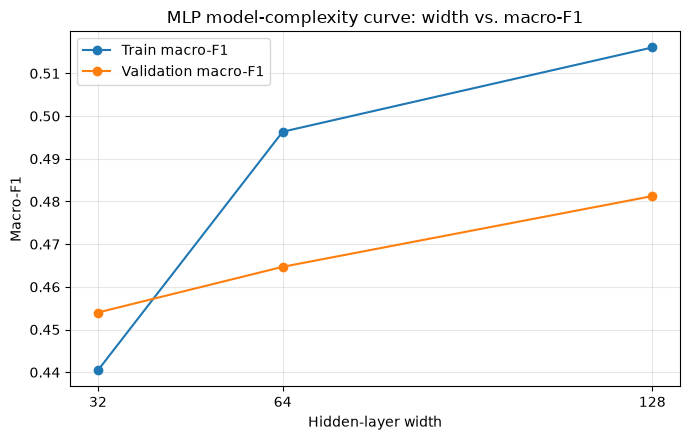

,width,alpha,train_macro_f1_at_best_epoch,val_macro_f1_at_best_epoch,best_epoch,fit_seconds
0,32,0.00001,0.440445,0.453987,97,21.800295
1,64,0.00100,0.496333,0.464694,100,25.866417
2,128,0.00010,0.516066,0.481255,100,34.263671


In [8]:
# Model-complexity curve: validation macro-F1 vs hidden width.
# To isolate width, use each width's best result over the tested alpha values.
complexity_df = (
    search_results
    .sort_values("val_macro_f1_at_best_epoch", ascending=False)
    .groupby("width", as_index=False)
    .first()
    .sort_values("width")
)

plt.figure(figsize=(7, 4.5))
plt.plot(complexity_df["width"], complexity_df["train_macro_f1_at_best_epoch"], marker="o", label="Train macro-F1")
plt.plot(complexity_df["width"], complexity_df["val_macro_f1_at_best_epoch"], marker="o", label="Validation macro-F1")
plt.xlabel("Hidden-layer width")
plt.ylabel("Macro-F1")
plt.title("MLP model-complexity curve: width vs. macro-F1")
plt.xticks(width_values)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_MODEL_COMPLEXITY_DIR / "01_mlp_model_complexity_width_macro_f1.png", dpi=200)
plt.show()

display(complexity_df[["width", "alpha", "train_macro_f1_at_best_epoch", "val_macro_f1_at_best_epoch", "best_epoch", "fit_seconds"]])

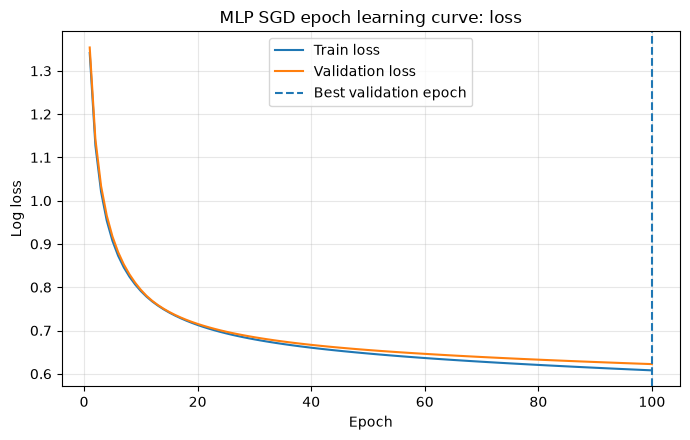

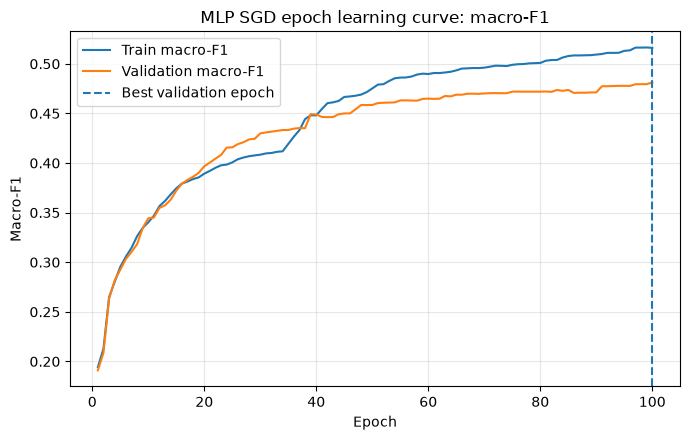

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_balanced_accuracy,val_balanced_accuracy
95,96,0.610275,0.624246,0.750000,0.73925,0.513568,0.477731,0.487247,0.467935
96,97,0.609680,0.623766,0.750062,0.73975,0.516337,0.479407,0.489439,0.469199
97,98,0.609090,0.623296,0.750000,0.74000,0.516357,0.479498,0.489420,0.469297
98,99,0.608506,0.622828,0.750375,0.74000,0.516481,0.479498,0.489543,0.469297
99,100,0.607927,0.622364,0.750437,0.74050,0.516106,0.481255,0.489669,0.470560


In [9]:
# Epoch-based curves for the selected validation operating point.
best_history = best["history"]

plt.figure(figsize=(7, 4.5))
plt.plot(best_history["epoch"], best_history["train_loss"], label="Train loss")
plt.plot(best_history["epoch"], best_history["val_loss"], label="Validation loss")
plt.axvline(best["info"]["best_epoch"], linestyle="--", label="Best validation epoch")
plt.xlabel("Epoch")
plt.ylabel("Log loss")
plt.title("MLP SGD epoch learning curve: loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "02_mlp_epoch_curve_loss.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(best_history["epoch"], best_history["train_macro_f1"], label="Train macro-F1")
plt.plot(best_history["epoch"], best_history["val_macro_f1"], label="Validation macro-F1")
plt.axvline(best["info"]["best_epoch"], linestyle="--", label="Best validation epoch")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("MLP SGD epoch learning curve: macro-F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "03_mlp_epoch_curve_macro_f1.png", dpi=200)
plt.show()

best_history.to_csv(RESULTS_MODEL_COMPARISON_DIR / "mlp_sgd_best_epoch_history.csv", index=False)
display(best_history.tail())

## Learning curve by training size

This section fixes the selected hyperparameters and varies the amount of training data. The validation set remains unchanged. This diagnoses bias/variance and whether more data appears useful.

In [10]:
train_size_fracs = [0.10, 0.25, 0.50, 0.75, 1.00]
learning_rows = []

selected_width = int(best["width"])
selected_alpha = float(best["alpha"])

for frac in train_size_fracs:
    if frac < 1.0:
        X_sub, _, y_sub, _ = train_test_split(
            X_train,
            y_train,
            train_size=frac,
            random_state=RANDOM_STATE,
            stratify=y_train,
        )
    else:
        X_sub, y_sub = X_train, y_train

    X_sub_s, X_val_sub_s = scale_train_val_test(X_sub, X_val)

    model, hist, info = fit_mlp_with_epoch_history(
        X_sub_s,
        y_sub,
        X_val_sub_s,
        y_val,
        width=selected_width,
        alpha=selected_alpha,
        learning_rate_init=learning_rate_init,
        batch_size=batch_size,
        max_epochs=max_epochs,
        patience=patience,
        random_state=RANDOM_STATE,
    )

    pred_start = time.perf_counter()
    val_pred = model.predict(X_val_sub_s)
    predict_seconds_val = time.perf_counter() - pred_start

    train_pred = model.predict(X_sub_s)

    learning_rows.append({
        "train_fraction": frac,
        "train_rows": len(X_sub),
        "width": selected_width,
        "alpha": selected_alpha,
        "best_epoch": info["best_epoch"],
        "epochs_run": info["epochs_run"],
        "fit_seconds": info["fit_seconds"],
        "predict_seconds_validation": predict_seconds_val,
        "train_accuracy": accuracy_score(y_sub, train_pred),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "train_macro_f1": f1_score(y_sub, train_pred, average="macro", zero_division=0),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro", zero_division=0),
        "train_balanced_accuracy": balanced_accuracy_score(y_sub, train_pred),
        "val_balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
    })

learning_curve_df = pd.DataFrame(learning_rows)
learning_curve_df.to_csv(RESULTS_MODEL_COMPARISON_DIR / "03_mlp_sgd_learning_curve_by_training_size.csv", index=False)
display(learning_curve_df)

,train_fraction,train_rows,width,alpha,best_epoch,epochs_run,fit_seconds,predict_seconds_validation,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_balanced_accuracy,val_balanced_accuracy
0,0.10,1600,128,0.00001,99,100,12.025174,0.010257,0.705000,0.6710,0.380552,0.356641,0.388105,0.366079
1,0.25,4000,128,0.00001,100,100,19.395712,0.013710,0.742250,0.7110,0.498873,0.431821,0.481874,0.435206
2,0.50,8000,128,0.00001,99,100,26.374262,0.014610,0.740500,0.7300,0.501088,0.460978,0.480863,0.455019
3,0.75,12000,128,0.00001,94,100,29.602302,0.006537,0.742667,0.7315,0.503591,0.462027,0.482397,0.456679
4,1.00,16000,128,0.00001,100,100,30.369243,0.012248,0.750437,0.7405,0.516106,0.481255,0.489669,0.470560


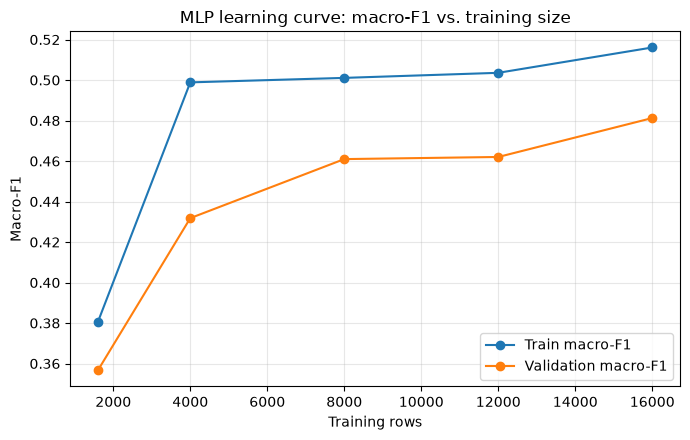

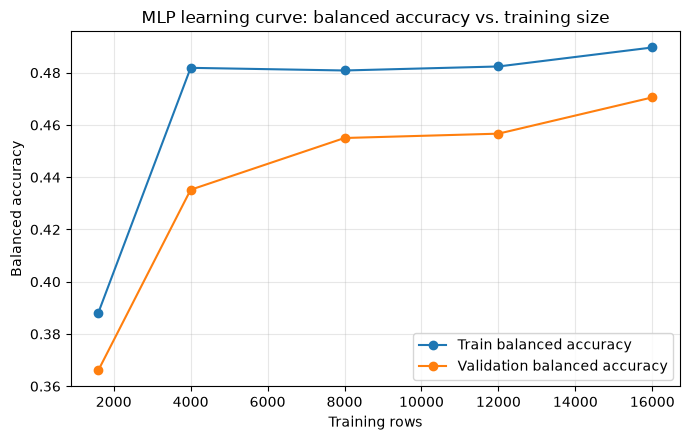

In [11]:
plt.figure(figsize=(7, 4.5))
plt.plot(learning_curve_df["train_rows"], learning_curve_df["train_macro_f1"], marker="o", label="Train macro-F1")
plt.plot(learning_curve_df["train_rows"], learning_curve_df["val_macro_f1"], marker="o", label="Validation macro-F1")
plt.xlabel("Training rows")
plt.ylabel("Macro-F1")
plt.title("MLP learning curve: macro-F1 vs. training size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "04_mlp_learning_curve_training_size_macro_f1.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(learning_curve_df["train_rows"], learning_curve_df["train_balanced_accuracy"], marker="o", label="Train balanced accuracy")
plt.plot(learning_curve_df["train_rows"], learning_curve_df["val_balanced_accuracy"], marker="o", label="Validation balanced accuracy")
plt.xlabel("Training rows")
plt.ylabel("Balanced accuracy")
plt.title("MLP learning curve: balanced accuracy vs. training size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "05_mlp_learning_curve_training_size_balanced_accuracy.png", dpi=200)
plt.show()

## Final evaluation on the held-out test set

The final model uses the validation-selected hidden width, L2 regularization, and best epoch. The operating point is standard multiclass argmax over predicted class probabilities because no asymmetric misclassification cost or class-specific threshold policy is specified.

The final test set comes from `DATA_PATH_TEST`, not from a random split of `DATA_PATH`.

In [12]:
# Refit the selected model on the 80% training split and use the 20% validation split for early stopping.
# The held-out test data from DATA_PATH_TEST remains untouched until evaluation below.
X_train_s, X_val_s, X_test_s = scale_train_val_test(X_train, X_val, X_test)

final_model, final_history, final_info = fit_mlp_with_epoch_history(
    X_train_s,
    y_train,
    X_val_s,
    y_val,
    width=selected_width,
    alpha=selected_alpha,
    learning_rate_init=learning_rate_init,
    batch_size=batch_size,
    max_epochs=max_epochs,
    patience=patience,
    random_state=RANDOM_STATE,
)

fit_seconds_final = final_info["fit_seconds"]

pred_start = time.perf_counter()
y_test_pred = final_model.predict(X_test_s)
predict_seconds_test = time.perf_counter() - pred_start

test_metrics = compute_basic_metrics(y_test, y_test_pred)
metrics_df = pd.DataFrame([{
    "model": "MLPClassifier_SGD_no_momentum",
    "width": selected_width,
    "alpha": selected_alpha,
    "learning_rate_init": learning_rate_init,
    "batch_size": batch_size,
    "best_epoch": final_info["best_epoch"],
    **test_metrics,
}])
metrics_df.to_csv(RESULTS_METRICS_DIR / "mlp_sgd_test_metrics.csv", index=False)
display(metrics_df)

runtime_df = pd.DataFrame([{
    "model": "MLPClassifier_SGD_no_momentum",
    "train_rows": len(X_train),
    "validation_rows": len(X_val),
    "test_rows": len(X_test),
    "fit_seconds": fit_seconds_final,
    "predict_seconds_test": predict_seconds_test,
    "epochs_run": final_info["epochs_run"],
    "best_epoch": final_info["best_epoch"],
    "hardware_note": json.dumps(hardware_note),
}])
runtime_df.to_csv(RESULTS_RUNTIME_DIR / "06_mlp_sgd_runtime_table.csv", index=False)
display(runtime_df)

,model,width,alpha,learning_rate_init,batch_size,best_epoch,accuracy,macro_f1,balanced_accuracy
0,MLPClassifier_SGD_no_momentum,128,0.00001,0.01,256,100,0.737733,0.493518,0.473979


,model,train_rows,validation_rows,test_rows,fit_seconds,predict_seconds_test,epochs_run,best_epoch,hardware_note
0,MLPClassifier_SGD_no_momentum,16000,4000,561012,30.082278,1.20374,100,100,"{""platform"": ""Linux-6.8.0-124-generic-x86_64-w..."


,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7
Actual 1,147316,53003,121,0,1,5,4102
Actual 2,44255,223051,4359,8,95,1175,606
Actual 3,0,3693,29402,252,0,1176,0
Actual 4,0,0,1957,532,0,164,0
Actual 5,159,8188,390,0,421,8,0
Actual 6,47,4890,9546,112,0,2174,0
Actual 7,8633,190,0,0,0,0,10981


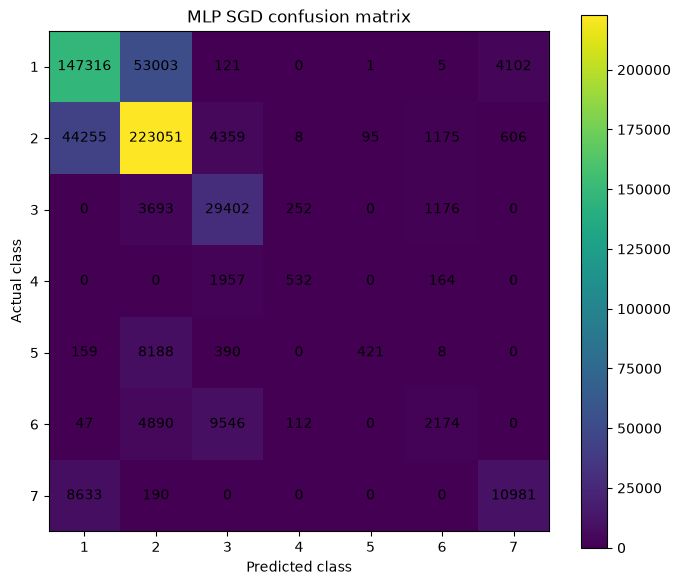

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=class_labels)
cm_df = pd.DataFrame(cm, index=[f"Actual {c}" for c in class_labels], columns=[f"Pred {c}" for c in class_labels])
cm_df.to_csv(RESULTS_CONFUSION_MATRICES_DIR / "mlp_sgd_confusion_matrix.csv")
display(cm_df)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("MLP SGD confusion matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.xticks(range(len(class_labels)), class_labels)
plt.yticks(range(len(class_labels)), class_labels)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig(FIG_CONFUSION_MATRICES_DIR / "06_mlp_sgd_confusion_matrix.png", dpi=200)
plt.show()

In [14]:
# Per-class precision, recall, F1
report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=class_labels,
    output_dict=True,
    zero_division=0,
)

per_class_df = pd.DataFrame(report_dict).T
per_class_df.to_csv(RESULTS_METRICS_DIR / "07_mlp_sgd_classification_report.csv")
display(per_class_df)

,precision,recall,f1-score,support
1,0.735073,0.720203,0.727562,204548.000000
2,0.761227,0.815397,0.787381,273549.000000
3,0.642316,0.851664,0.732322,34523.000000
4,0.588496,0.200528,0.299128,2653.000000
5,0.814313,0.045931,0.086957,9166.000000
6,0.462356,0.129644,0.202506,16769.000000
7,0.699917,0.554484,0.618770,19804.000000
accuracy,0.737733,0.737733,0.737733,0.737733
macro avg,0.671957,0.473979,0.493518,561012.000000
weighted avg,0.733327,0.737733,0.724996,561012.000000


## Report-ready interpretation

Run the cell below after the experiment finishes. It prints a concise paragraph set using the actual measured values.

In [15]:
def format_pct(x):
    return f"{x:.3f}"

per_class_only = per_class_df.loc[[str(c) for c in class_labels]].copy()
per_class_only["class"] = per_class_only.index.astype(int)
lowest_f1 = per_class_only.sort_values("f1-score").head(2)
lowest_recall = per_class_only.sort_values("recall").head(2)

last_learning = learning_curve_df.iloc[-1]
first_learning = learning_curve_df.iloc[0]

print("REPORT NOTES")
print("=" * 80)
print(
    f"The selected MLPClassifier used solver='sgd', momentum=0, and nesterovs_momentum=False. "
    f"The best validation setting was width={selected_width}, alpha={selected_alpha:g}, "
    f"learning_rate_init={learning_rate_init}, selected at epoch {final_info['best_epoch']}."
)
print()
print(
    f"On the held-out DATA_PATH_TEST remainder test set, the model achieved accuracy={format_pct(test_metrics['accuracy'])}, "
    f"macro-F1={format_pct(test_metrics['macro_f1'])}, and balanced accuracy={format_pct(test_metrics['balanced_accuracy'])}. "
    "Accuracy summarizes overall correctness, but macro-F1 and balanced accuracy are more informative for this imbalanced "
    "seven-class dataset because they reduce dominance by the majority classes."
)
print()
print(
    f"The weakest classes by F1 were {lowest_f1['class'].tolist()}, and the weakest classes by recall were "
    f"{lowest_recall['class'].tolist()}. These classes should be discussed as the main minority-class or boundary-confusion "
    "limitations if their F1/recall values are substantially below the majority-class scores."
)
print()
print(
    f"The learning curve changed from validation macro-F1={format_pct(first_learning['val_macro_f1'])} "
    f"at {int(first_learning['train_rows'])} training rows to validation macro-F1={format_pct(last_learning['val_macro_f1'])} "
    f"at {int(last_learning['train_rows'])} training rows. If validation performance continues rising while the train-validation gap "
    "shrinks, more data is likely to help. If both curves flatten at a low value, the model is underfitting; if training remains much "
    "higher than validation, the model has high variance."
)
print()
print(
    f"Runtime on this hardware was fit_seconds={fit_seconds_final:.3f} and "
    f"predict_seconds_test={predict_seconds_test:.6f} for {len(X_test)} test rows."
)

REPORT NOTES
The selected MLPClassifier used solver='sgd', momentum=0, and nesterovs_momentum=False. The best validation setting was width=128, alpha=1e-05, learning_rate_init=0.01, selected at epoch 100.

On the held-out DATA_PATH_TEST remainder test set, the model achieved accuracy=0.738, macro-F1=0.494, and balanced accuracy=0.474. Accuracy summarizes overall correctness, but macro-F1 and balanced accuracy are more informative for this imbalanced seven-class dataset because they reduce dominance by the majority classes.

The weakest classes by F1 were [5, 6], and the weakest classes by recall were [5, 6]. These classes should be discussed as the main minority-class or boundary-confusion limitations if their F1/recall values are substantially below the majority-class scores.

The learning curve changed from validation macro-F1=0.357 at 1600 training rows to validation macro-F1=0.481 at 16000 training rows. If validation performance continues rising while the train-validation gap shri

## Metric discussion template

Use the measured numbers above to fill the final report. The discussion should cover:

- **Accuracy:** useful as a compact overall correctness score, but not enough because classes are imbalanced.
- **Macro-F1:** averages F1 equally across classes, so poor minority-class performance lowers the score.
- **Balanced accuracy:** averages recall across classes and exposes whether the model misses minority cover types.
- **Confusion matrix:** shows which cover types are systematically confused.
- **Per-class precision/recall/F1:** identifies whether minority classes suffer from low recall, low precision, or both.
- **Early stopping:** the chosen epoch is the epoch with best validation macro-F1; this controls over-training without using the test set.
- **Regularization:** L2 `alpha` controls weight size. Too little L2 can overfit; too much L2 can underfit and flatten class boundaries.